# 02 · Reglas de asociación

## Definición del problema

Buscamos patrones de co-ocurrencia entre los hábitos de los estudiantes y su rendimiento académico usando **reglas de asociación**, sobre el dataset discretizado en `01_exploracion_discretizacion.ipynb`.

**Formulación:**

- **Transacción:** un estudiante (una fila del dataset limpio).
- **Ítem:** un par `variable=valor`. Las numéricas participan por su cuartil (ej. `gaming_hours=Q4`, el 25% que más juega) y las categóricas por su categoría (ej. `stress_level=High`). Cada transacción contiene exactamente 13 ítems, uno por variable.
- **Regla** $X \Rightarrow Y$: si una transacción contiene el conjunto de ítems $X$ (antecedente), tiende a contener también $Y$ (consecuente).

**Métricas:**

$$\mathrm{soporte}(X \Rightarrow Y) = P(X \cup Y) \qquad \mathrm{confianza}(X \Rightarrow Y) = \frac{\mathrm{sop}(X \cup Y)}{\mathrm{sop}(X)} \qquad \mathrm{lift}(X \Rightarrow Y) = \frac{\mathrm{conf}(X \Rightarrow Y)}{\mathrm{sop}(Y)}$$

Un lift > 1 indica que antecedente y consecuente co-ocurren más de lo esperado por azar.

**Preguntas que definimos:**

1. **P1 — minería abierta:** ¿qué patrones globales co-ocurren con más fuerza? En particular, ¿existen grupos de variables redundantes entre sí? Esto informa la selección de features para la red neuronal que cierra el proyecto.
2. **P2 — foco en notas:** ¿qué combinaciones de hábitos se asocian a cada banda de calificación (`grades=Q1` … `grades=Q4`)? Es la versión interpretable y descriptiva del problema de estimación de notas.

**Algoritmo:** Apriori (`mlxtend`), que enumera los itemsets frecuentes sobre un umbral de soporte mínimo y deriva reglas desde ellos.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules

# raíz del repo, funcione el kernel desde notebooks/ (default de Jupyter) o desde la raíz
REPO = Path.cwd().resolve()
if REPO.name == 'notebooks':
    REPO = REPO.parent
PROCESSED = REPO / 'data' / 'processed' / 'dataset_discretizado.csv'

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

df = pd.read_csv(PROCESSED)
print('Dimensiones:', df.shape)
df.head()

Dimensiones: (7865, 13)


,gender,gaming_genre,stress_level,age,gaming_hours,study_hours,sleep_hours,attendance,social_activity,device_usage,reaction_time_ms,addiction_score,grades
0,Male,FPS,Low,Q3,Q4,Q4,Q3,Q4,Q3,Q3,Q1,Q4,Q4
1,Male,Casual,Medium,Q2,Q1,Q4,Q3,Q1,Q1,Q1,Q4,Q1,Q4
2,Female,Casual,High,Q4,Q1,Q4,Q1,Q3,Q3,Q1,Q4,Q1,Q4
3,Female,RPG,Low,Q2,Q4,Q1,Q4,Q2,Q2,Q4,Q1,Q4,Q1
4,Female,FPS,Low,Q3,Q3,Q3,Q2,Q1,Q1,Q3,Q2,Q3,Q2


## Representación transaccional

Apriori espera una matriz booleana transacción × ítem. `pd.get_dummies` convierte cada `variable=valor` en una columna.

In [2]:
onehot = pd.get_dummies(df, prefix_sep='=').astype(bool)
print('Transacciones:', onehot.shape[0], '| ítems posibles:', onehot.shape[1])
print('Ítems por transacción:', onehot.sum(axis=1).unique())
sorted(onehot.columns)

Transacciones: 7865 | ítems posibles: 49
Ítems por transacción: [13]


['addiction_score=Q1',
 'addiction_score=Q2',
 'addiction_score=Q3',
 'addiction_score=Q4',
 'age=Q1',
 'age=Q2',
 'age=Q3',
 'age=Q4',
 'attendance=Q1',
 'attendance=Q2',
 'attendance=Q3',
 'attendance=Q4',
 'device_usage=Q1',
 'device_usage=Q2',
 'device_usage=Q3',
 'device_usage=Q4',
 'gaming_genre=Casual',
 'gaming_genre=FPS',
 'gaming_genre=RPG',
 'gaming_hours=Q1',
 'gaming_hours=Q2',
 'gaming_hours=Q3',
 'gaming_hours=Q4',
 'gender=Female',
 'gender=Male',
 'gender=Other',
 'grades=Q1',
 'grades=Q2',
 'grades=Q3',
 'grades=Q4',
 'reaction_time_ms=Q1',
 'reaction_time_ms=Q2',
 'reaction_time_ms=Q3',
 'reaction_time_ms=Q4',
 'sleep_hours=Q1',
 'sleep_hours=Q2',
 'sleep_hours=Q3',
 'sleep_hours=Q4',
 'social_activity=Q1',
 'social_activity=Q2',
 'social_activity=Q3',
 'social_activity=Q4',
 'stress_level=High',
 'stress_level=Low',
 'stress_level=Medium',
 'study_hours=Q1',
 'study_hours=Q2',
 'study_hours=Q3',
 'study_hours=Q4']

## Itemsets frecuentes

**Elección de `min_support = 0.05`:** los cuartiles son balanceados, así que un ítem individual tiene soporte ≈ 0.25 y un par de ítems *independientes* ≈ 0.0625. Con umbral 0.05 conservamos prácticamente todos los pares (para no perder asociaciones débiles pero reales) mientras que los tríos (≈ 0.016 bajo independencia) solo sobreviven si están genuinamente correlacionados. `max_len=4` acota el tamaño de los antecedentes a algo interpretable.

In [3]:
frecuentes = apriori(onehot, min_support=0.05, use_colnames=True, max_len=4)
frecuentes['n_items'] = frecuentes['itemsets'].apply(len)
print('Itemsets frecuentes:', len(frecuentes))
print(frecuentes['n_items'].value_counts().sort_index())

Itemsets frecuentes: 1767
n_items
1     48
2    929
3    629
4    161
Name: count, dtype: int64


In [4]:
# pares y tríos más frecuentes: primer vistazo a qué co-ocurre
frecuentes[frecuentes['n_items'] >= 2].sort_values('support', ascending=False).head(10)

,support,itemsets,n_items
99,0.261284,"frozenset({gender=Male, stress_level=Medium})",2
53,0.248951,"frozenset({gender=Female, stress_level=Medium})",2
303,0.219580,"frozenset({gaming_hours=Q1, stress_level=Medium})",2
327,0.219072,"frozenset({reaction_time_ms=Q4, stress_level=M...",2
183,0.218945,"frozenset({gaming_genre=FPS, stress_level=Medi...",2
274,0.218309,"frozenset({stress_level=Low, gaming_hours=Q4})",2
322,0.218182,"frozenset({device_usage=Q1, stress_level=Medium})",2
304,0.217800,"frozenset({gaming_hours=Q2, stress_level=Medium})",2
328,0.216910,"frozenset({addiction_score=Q1, stress_level=Me...",2
293,0.214749,"frozenset({stress_level=Low, reaction_time_ms=...",2


## P1 · Minería abierta

Generamos todas las reglas con **lift ≥ 1.1** (asociación positiva por sobre el azar) y las ordenamos por lift.

In [5]:
reglas = association_rules(frecuentes, metric='lift', min_threshold=1.1)

def fmt(itemset):
    return ' + '.join(sorted(itemset))

reglas['antecedente'] = reglas['antecedents'].apply(fmt)
reglas['consecuente'] = reglas['consequents'].apply(fmt)
cols = ['antecedente', 'consecuente', 'support', 'confidence', 'lift']

print('Reglas con lift >= 1.1:', len(reglas))
reglas.sort_values('lift', ascending=False)[cols].head(15).round(3)

Reglas con lift >= 1.1: 4808


,antecedente,consecuente,support,confidence,lift
1013,sleep_hours=Q1 + study_hours=Q4,stress_level=High,0.062,1.000,7.961
1016,stress_level=High,sleep_hours=Q1 + study_hours=Q4,0.062,0.494,7.961
4631,gaming_hours=Q1 + study_hours=Q4,grades=Q4 + reaction_time_ms=Q4,0.051,0.823,7.158
4634,grades=Q4 + reaction_time_ms=Q4,gaming_hours=Q1 + study_hours=Q4,0.051,0.441,7.158
4633,gaming_hours=Q1 + grades=Q4,reaction_time_ms=Q4 + study_hours=Q4,0.051,0.418,6.755
4632,reaction_time_ms=Q4 + study_hours=Q4,gaming_hours=Q1 + grades=Q4,0.051,0.819,6.755
4718,gaming_hours=Q4 + study_hours=Q1,grades=Q1 + reaction_time_ms=Q1,0.050,0.826,6.328
4715,grades=Q1 + reaction_time_ms=Q1,gaming_hours=Q4 + study_hours=Q1,0.050,0.385,6.328
4717,reaction_time_ms=Q1 + study_hours=Q1,gaming_hours=Q4 + grades=Q1,0.050,0.825,6.016
4716,gaming_hours=Q4 + grades=Q1,reaction_time_ms=Q1 + study_hours=Q1,0.050,0.366,6.016


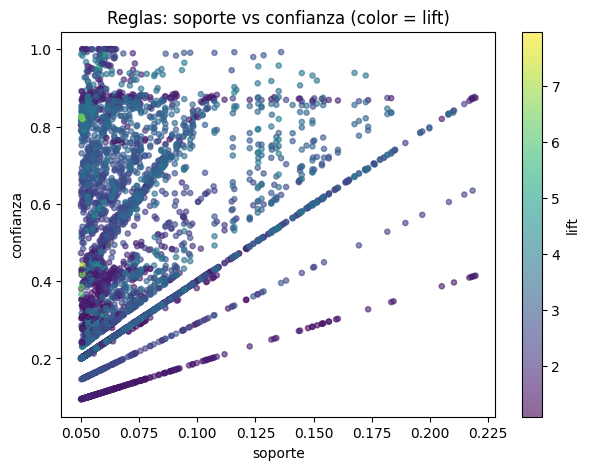

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(reglas['support'], reglas['confidence'], c=reglas['lift'], cmap='viridis', s=14, alpha=0.6)
fig.colorbar(sc, label='lift')
ax.set_xlabel('soporte')
ax.set_ylabel('confianza')
ax.set_title('Reglas: soporte vs confianza (color = lift)')
plt.show()

In [7]:
# P1: redundancia 1-a-1 dentro del cluster de juego detectado en el EDA del equipo (|r| 0.79–0.94)
cluster = {'gaming_hours', 'device_usage', 'addiction_score', 'reaction_time_ms'}

def item_en_cluster(itemset):
    return len(itemset) == 1 and next(iter(itemset)).split('=')[0] in cluster

intra = reglas[reglas['antecedents'].apply(item_en_cluster) & reglas['consequents'].apply(item_en_cluster)]
print('Reglas 1-a-1 dentro del cluster:', len(intra))
intra.sort_values('lift', ascending=False)[cols].head(12).round(3)

Reglas 1-a-1 dentro del cluster: 68


,antecedente,consecuente,support,confidence,lift
69,reaction_time_ms=Q4,gaming_hours=Q1,0.210,0.840,3.343
68,gaming_hours=Q1,reaction_time_ms=Q4,0.210,0.836,3.343
110,reaction_time_ms=Q1,gaming_hours=Q4,0.208,0.831,3.324
111,gaming_hours=Q4,reaction_time_ms=Q1,0.208,0.832,3.324
70,addiction_score=Q1,gaming_hours=Q1,0.200,0.798,3.176
71,gaming_hours=Q1,addiction_score=Q1,0.200,0.795,3.176
113,gaming_hours=Q4,addiction_score=Q4,0.196,0.783,3.138
112,addiction_score=Q4,gaming_hours=Q4,0.196,0.785,3.138
200,addiction_score=Q1,reaction_time_ms=Q4,0.185,0.739,2.956
201,reaction_time_ms=Q4,addiction_score=Q1,0.185,0.740,2.956


### Hallazgo P1: estructura y redundancia

**Una regla determinista delata al generador:** `{sleep_hours=Q1 + study_hours=Q4} → {stress_level=High}` tiene **confianza 1.000** (lift 7.96): el 100% de quienes duermen poco y estudian mucho aparece con estrés alto. En datos de conducta reales no existen reglas perfectas; `stress_level` parece *calculado* a partir de sueño y estudio, no medido por separado.

**Redundancia del cluster de juego (tabla anterior):** hay 68 reglas 1-a-1 entre `gaming_hours`, `reaction_time_ms`, `addiction_score` y `device_usage`. Las más fuertes: `gaming_hours=Q1 ↔ reaction_time_ms=Q4` (confianza ≈ 0.84, lift 3.34) y `gaming_hours ↔ addiction_score` (confianza ≈ 0.80, lift 3.18). Conocer el cuartil de una de estas variables permite acertar el de las otras ~80% de las veces: las cuatro miden esencialmente lo mismo (cuánto juega la persona). Nótese la dirección de `reaction_time_ms`: quienes más juegan reaccionan *más rápido* (menos ms), por eso Q4 de juego empareja con Q1 de reacción.

**Implicancia para el proyecto:** en la red neuronal conviene tratar el cluster como una sola señal (p. ej. conservar `gaming_hours` y descartar o combinar las otras tres) y mirar `stress_level` con sospecha de *leakage*, ya que es función de otras dos columnas.

## P2 · Reglas hacia bandas de nota

Filtramos las reglas cuyo **consecuente es exactamente una banda de `grades`**: describen qué combinaciones de hábitos co-ocurren con notas bajas (`Q1`) o altas (`Q4`).

In [8]:
items_nota = {f'grades=Q{i}' for i in range(1, 5)}
es_nota = reglas['consequents'].apply(lambda s: len(s) == 1 and next(iter(s)) in items_nota)
reglas_nota = reglas[es_nota].copy()
print('Reglas con consecuente = banda de nota:', len(reglas_nota))

top_por_banda = (reglas_nota.sort_values('lift', ascending=False)
                 .groupby('consecuente')
                 .head(5)
                 .sort_values(['consecuente', 'lift'], ascending=[True, False]))
top_por_banda[cols].round(3)

Reglas con consecuente = banda de nota: 213


,antecedente,consecuente,support,confidence,lift
4713,gaming_hours=Q4 + reaction_time_ms=Q1 + study_...,grades=Q1,0.050,0.988,3.948
2510,gaming_hours=Q4 + study_hours=Q1,grades=Q1,0.060,0.985,3.940
3907,gaming_hours=Q4 + stress_level=Low + study_hou...,grades=Q1,0.060,0.985,3.940
4089,addiction_score=Q4 + stress_level=Low + study_...,grades=Q1,0.056,0.971,3.884
4075,reaction_time_ms=Q1 + stress_level=Low + study...,grades=Q1,0.058,0.970,3.880
1734,stress_level=Medium + study_hours=Q1,grades=Q2,0.076,0.502,2.006
1770,stress_level=Medium + study_hours=Q2,grades=Q2,0.060,0.405,1.619
123,study_hours=Q2,grades=Q2,0.088,0.353,1.410
2186,addiction_score=Q2 + stress_level=Medium,grades=Q2,0.069,0.334,1.336
1676,gaming_hours=Q2 + stress_level=Medium,grades=Q2,0.072,0.332,1.328


In [9]:
# foco en los extremos: ¿qué acompaña a las notas más bajas y más altas?
for banda in ['grades=Q1', 'grades=Q4']:
    print(f'--- {banda} ---')
    sub = reglas_nota[reglas_nota['consecuente'] == banda]
    print(sub.sort_values('lift', ascending=False)[cols].head(8).round(3).to_string(index=False))
    print()

--- grades=Q1 ---
                                            antecedente consecuente  support  confidence  lift
 gaming_hours=Q4 + reaction_time_ms=Q1 + study_hours=Q1   grades=Q1    0.050       0.988 3.948
                       gaming_hours=Q4 + study_hours=Q1   grades=Q1    0.060       0.985 3.940
    gaming_hours=Q4 + stress_level=Low + study_hours=Q1   grades=Q1    0.060       0.985 3.940
 addiction_score=Q4 + stress_level=Low + study_hours=Q1   grades=Q1    0.056       0.971 3.884
reaction_time_ms=Q1 + stress_level=Low + study_hours=Q1   grades=Q1    0.058       0.970 3.880
    device_usage=Q4 + stress_level=Low + study_hours=Q1   grades=Q1    0.052       0.967 3.867
                   reaction_time_ms=Q1 + study_hours=Q1   grades=Q1    0.059       0.967 3.865
                    addiction_score=Q4 + study_hours=Q1   grades=Q1    0.057       0.966 3.861

--- grades=Q4 ---
                                           antecedente consecuente  support  confidence  lift
gaming_hours=Q

### Hallazgo P2: hábitos asociados al rendimiento

De las 4808 reglas, 213 tienen como consecuente una banda de nota. Los extremos son nítidos y casi simétricos:

- **Notas bajas:** `{gaming_hours=Q4 + study_hours=Q1} → grades=Q1` con confianza **0.985** y lift 3.94: el 98.5% de quienes más juegan (> 6.1 h) y menos estudian (< 3.2 h) cae en el cuartil inferior de notas (< 49.5 puntos).
- **Notas altas:** el patrón espejo `{gaming_hours=Q1 + study_hours=Q4} → grades=Q4` con confianza **0.981** y lift 3.93.
- **`study_hours` manda:** aparece en todas las reglas fuertes hacia notas. Sumarle variables del cluster de juego apenas mueve la confianza (0.93 → 0.99), consistente con la redundancia encontrada en P1.
- **El centro es difuso:** las bandas intermedias Q2 y Q3 solo alcanzan lift ≤ 2.0 y confianzas ≤ 0.5 — los hábitos extremos discriminan notas extremas, pero no separan bien el medio.
- `reaction_time_ms`, `addiction_score` y `device_usage` aparecen en estas reglas como **proxies** de `gaming_hours`, no como información nueva.

Confianzas de 0.93–0.99 con soporte ≥ 0.05 son inusualmente altas para datos de comportamiento: otra huella de un dataset sintético con relaciones casi deterministas.

## Conclusiones

1. **Problema definido y resuelto:** 7865 transacciones (estudiantes) × 49 ítems (cuartiles + categorías); Apriori con soporte ≥ 0.05 produjo 1767 itemsets frecuentes y 4808 reglas con lift ≥ 1.1.
2. **P1 — el dataset es estructuralmente redundante:** el cluster `gaming_hours` / `device_usage` / `addiction_score` / `reaction_time_ms` se predice mutuamente (confianza ≈ 0.72–0.84, lift ≈ 2.9–3.3), y `stress_level` resulta función determinista de sueño + estudio (confianza 1.0). Para la red neuronal: usar **una** señal del cluster y evaluar excluir `stress_level` por leakage.
3. **P2 — estudio y juego en extremos casi determinan la banda de nota:** `{study=Q1 + gaming=Q4} → grades=Q1` y su espejo, con confianza ≈ 0.98 y lift ≈ 3.9. Esto anticipa que el modelo de regresión va a encontrar señal fuerte y monótona (el EDA ya mostraba r = +0.73 estudio y r = −0.55 juego); las bandas intermedias, en cambio, serán la zona de mayor error.

**Limitaciones:**

- Dataset sintético (Kaggle): las asociaciones reflejan cómo se generó el dato, no necesariamente conducta real; reglas con confianza ≈ 1 no ocurren en datos de comportamiento reales.
- Asociación no es causalidad: una regla `gaming=Q4 → grades=Q1` no prueba que jugar baje las notas.
- La discretización por cuartiles pierde granularidad dentro de cada banda; el modelo de regresión posterior trabajará sobre los valores continuos.